# Базова регресія

Регресія - спосіб аналізу даних за якого по "точках" даних проводять лінію з меншою кількістю параметрів, 
ніж потенційно дозволяє набір даних.
Найпростіший варіант - проведення прямої лінії, яка має два параметри (для площини).

## Завдання 1
Потрібно побудувати просту модель лінійної регресії на одній ознаці й отримати передбачення:
- Завантажте вбудований датасет про діабет із бібліотеки scikit-learn.
- Виберіть одну ознаку (наприклад, індекс маси тіла — це ознака з індексом 2).
- Розділіть дані на навчальну і тестову вибірки (80/20).
- Побудуйте модель за допомогою класу LinearRegression з sklearn.linear_model.
- Отримайте передбачення на тестовій вибірці та виведіть перші 10 реальних і передбачених значень поруч.


In [2]:
# Завантажте вбудований датасет про діабет із бібліотеки scikit-learn
# Встановлюємо бібліотеку  pip install -U scikit-learn
# імпортуємо завантажувач
from sklearn.datasets import load_diabetes
import pandas as pd
# завантажуємо дані
diabetes = load_diabetes()

In [4]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
# Перетворюємо дані на DataFrame - єдину таблицю
df = pd.DataFrame( diabetes.data, columns=diabetes.feature_names )
df["target"] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [10]:
# Виберіть одну ознаку (наприклад, індекс маси тіла — це ознака з індексом 2).
data = df[["bmi", "target"]]
data.head()

,bmi,target
0,0.061696,151.0
1,-0.051474,75.0
2,0.044451,141.0
3,-0.011595,206.0
4,-0.036385,135.0


In [30]:
# Розділіть дані на навчальну і тестову вибірки (80/20).
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    data["bmi"].array.reshape(-1, 1),
    data["target"],
    test_size=0.2,
    random_state=1
)

print(f"Загальний набір з {len(data.index)} даних розбито на {len(xtrain)} навчальних та {len(xtest)} тестових позицій")

Загальний набір з 442 даних розбито на 353 навчальних та 89 тестових позицій


In [31]:
# Побудуйте модель за допомогою класу LinearRegression з sklearn.linear_model.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain, ytrain)
print(f"Результати навчання: коєф.: {model.coef_[0]}, доданок: {model.intercept_}")

Результати навчання: коєф.: 977.7404006688255, доданок: 151.66780594915235


In [32]:
# Отримайте передбачення на тестовій вибірці та виведіть перші 10 реальних і передбачених значень поруч.
prediction = pd.DataFrame({
    "bmi(x)": [x[0] for x in xtest],
    "real": ytest,
    "pred": model.predict(xtest),
})
prediction.head(10)

,bmi(x),real,pred
246,-0.032073,78.0,120.308304
425,-0.040696,152.0,111.877741
293,0.092953,200.0,242.551471
31,-0.065486,59.0,87.639871
359,0.005650,311.0,157.192018
437,0.019662,178.0,170.891684
290,0.076786,332.0,226.744165
439,-0.015906,132.0,136.115610
284,-0.022373,156.0,129.792688
4,-0.036385,135.0,116.093022


## Завдання 2
Необхідно візуально показати, як модель описує дані:
- Використовуйте ті самі дані та модель, що в завданні 1.
- Побудуйте scatter-графік: по осі X — значення ознаки, по осі Y — реальні значення цільової змінної.
- Поверх точок побудуйте пряму регресії (передбачення моделі).
- Додайте підписи осей і легенду.

In [33]:
import matplotlib.pyplot as plt

In [40]:
pred = model.predict(data["bmi"].array.reshape(-1,1))

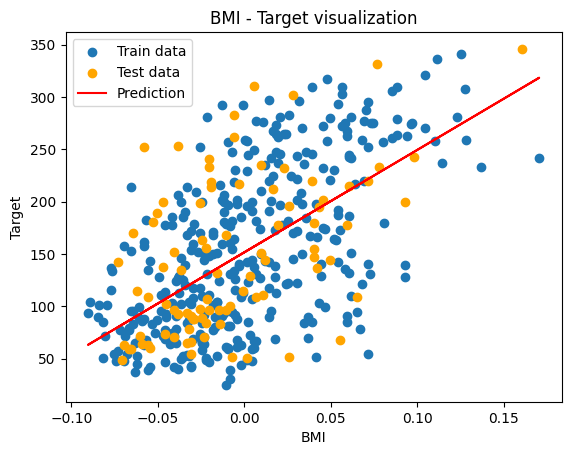

In [41]:
_, ax = plt.subplots()
ax.scatter(xtrain, ytrain, label="Train data")
ax.scatter(xtest, ytest, color="orange", label="Test data")
ax.plot(data["bmi"], pred, "-r", label="Prediction")
ax.legend()
ax.set_title("BMI - Target visualization")
ax.set_xlabel("BMI")
ax.set_ylabel("Target")
plt.show()

## Завдання 3
Потрібно виміряти якість побудованої моделі за допомогою метрик регресії:
- Використовуйте тестову вибірку із завдання 1.
- Обчисліть метрики за допомогою функцій з sklearn.metrics:
- mean_absolute_error — MAE (Mean Absolute Error);
- mean_squared_error — MSE (Mean Squared Error);
- r2_score — R² (коефіцієнт детермінації).
- Оформіть результати в таблиці:

|Метрика|Значення|
|-|-|
|MAE|...|
|MSE|...|
|R²|...|

In [46]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

mae = sm.mean_absolute_error(data["target"], pred)
mse = sm.mean_squared_error(data["target"], pred)
r2 = sm.r2_score(data["target"], pred)
md(f"""|Метрика|Значення|
|-|-|
|MAE|{mae:.2f}|
|MSE|{mse:.2f}|
|R²|{r2:.2f}|
""")

|Метрика|Значення|
|-|-|
|MAE|51.63|
|MSE|3892.49|
|R²|0.34|


## Завдання 4
Потрібно реалізувати простий варіант градієнтного спуску і порівняти його результат із моделлю, побудованою за допомогою класу LinearRegression.
- Використовуйте одну ознаку з датасету про діабет і цільову змінну.
- Реалізуйте функцію навчання лінійної регресії методом градієнтного спуску
- Навчіть модель і отримайте коефіцієнти (w, b).
- Порівняйте MAE вашої реалізації та результату моделі LinearRegression.

In [48]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(xtrain, ytrain)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

In [49]:
len(sgd.coef_)

197

In [53]:
sgd_pred = sgd.predict(data["bmi"].array.reshape(-1,1))
sgd_pred[:10]

array([242., 109., 242., 109., 109., 109., 109., 109., 242., 242.])

In [54]:
md(f"""|Метрика|Значення|SGD|
|-|-|-|
|MAE|{mae:.2f}|{sm.mean_absolute_error(data["target"], sgd_pred):.2f}|
|MSE|{mse:.2f}|{sm.mean_squared_error(data["target"], sgd_pred):.2f}|
|R²|{r2:.2f}|{sm.r2_score(data["target"], sgd_pred):.2f}|
""")

|Метрика|Значення|SGD|
|-|-|-|
|MAE|51.63|58.42|
|MSE|3892.49|5529.94|
|R²|0.34|0.07|
